# LSTM Baseline for WLASL Sign Recognition Using MediaPipe Landmarks

This notebook creates the **next baseline model after Random Forest and HMM**.

Random Forest used summarized landmark statistics.  
HMM used landmark sequences with a traditional probabilistic model.  
LSTM uses deep learning to learn movement patterns over time.

## Purpose

This model is for the **model comparison stage** of the project, not the final full translation system.

It helps compare:

- Random Forest: traditional non-temporal baseline
- HMM: traditional temporal baseline
- LSTM: deep learning temporal baseline
- Later models: ST-GCN and Transformers

In [3]:
# If torch is missing, uncomment this cell and run it once
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.2/192.2 MB 15.5 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 6.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 22.9 MB/s  0:00:00
  Attempting uninstall: setuptoolsm━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [sympy]]
    Found existing installation: setuptools 82.0.1━━━━━━━━━━━━ 2/6 [sympy]
    Uninstalling setuptools-82.0.1:0m╺━━━━━━━━━━━━━━━━━━━ 3/6 [setuptools]
      Successfully uninstalled setuptools-82.0.1━━━━━━━━━━━━━━━━━━ 3/6 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torchvision] [torchvision]


## 1. Imports

In [5]:
import os
import sys
import json
import random
import logging
from pathlib import Path
from datetime import datetime
from collections import Counter

import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import mediapipe as mp

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

print("Python:", sys.version)
print("MediaPipe:", getattr(mp, "__version__", "unknown"))
print("MediaPipe has solutions:", hasattr(mp, "solutions"))
print("Torch:", torch.__version__)
print("FiftyOne DB:", os.environ.get("FIFTYONE_DATABASE_URI"))

Python: 3.11.15 (main, May 19 2026, 23:49:45) [GCC 14.2.0]
MediaPipe: 0.10.21
MediaPipe has solutions: True
Torch: 2.12.0+cpu
FiftyOne DB: mongodb://mongo:27017


## 2. Project folders and logging

In [6]:
PROJECT_DIR = Path("/workspace/dataset/ksl_project_data").resolve()

if not Path("/workspace/dataset").exists():
    PROJECT_DIR = Path("ksl_project_data").resolve()

LOG_DIR = PROJECT_DIR / "logs"
FEATURE_DIR = PROJECT_DIR / "features"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [LOG_DIR, FEATURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

log_file = LOG_DIR / f"lstm_wlasl_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler(sys.stdout),
    ],
    force=True,
)

logger = logging.getLogger(__name__)
logger.info("LSTM notebook started")

print("Project directory:", PROJECT_DIR)

2026-06-05 11:11:08,301 | INFO | LSTM notebook started
Project directory: /workspace/dataset/ksl_project_data


## 3. Reproducibility

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 4. Load WLASL from FiftyOne

This uses the same dataset used in the Random Forest and HMM notebooks.

In [8]:
DATASET_NAME = "Voxel51/WLASL"

if DATASET_NAME in fo.list_datasets():
    logger.info("Loading existing local WLASL dataset")
    dataset = fo.load_dataset(DATASET_NAME)
else:
    logger.info("Loading WLASL from Hugging Face/FiftyOne hub")
    dataset = fouh.load_from_hub(DATASET_NAME, persistent=True)

dataset.persistent = True

print("Dataset:", dataset.name)
print("Total samples:", len(dataset))
print("Fields:", dataset.get_field_schema())

2026-06-05 11:14:11,871 | INFO | Loading existing local WLASL dataset
Dataset: Voxel51/WLASL
Total samples: 11980
Fields: OrderedDict([('id', <fiftyone.core.fields.ObjectIdField object at 0x7f1697c8dcd0>), ('filepath', <fiftyone.core.fields.StringField object at 0x7f16ab46ae50>), ('tags', <fiftyone.core.fields.ListField object at 0x7f16e30387d0>), ('metadata', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f16aadfd8d0>), ('created_at', <fiftyone.core.fields.DateTimeField object at 0x7f16ab4697d0>), ('last_modified_at', <fiftyone.core.fields.DateTimeField object at 0x7f1695813790>), ('bounding_box', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f1695818610>), ('gloss', <fiftyone.core.fields.EmbeddedDocumentField object at 0x7f16dbce0a10>)])


## 5. Label extraction helper

In [9]:
def get_label_from_sample(sample):
    candidate_fields = ["ground_truth", "label", "labels", "classification", "word", "gloss"]

    for field in candidate_fields:
        if field in sample:
            value = sample[field]
            if value is None:
                continue
            if hasattr(value, "label"):
                return value.label
            if isinstance(value, str):
                return value

    for field in sample.field_names:
        value = sample[field]
        if hasattr(value, "label"):
            return value.label
        if field.lower() in ["word", "gloss", "label"] and isinstance(value, str):
            return value

    return None


labels = []
for sample in dataset:
    label = get_label_from_sample(sample)
    if label is not None:
        labels.append(label)

label_counts = Counter(labels)

print("Total labelled samples:", len(labels))
print("Unique labels:", len(label_counts))
print("Top labels:")
for label, count in label_counts.most_common(20):
    print(label, count)

Total labelled samples: 11980
Unique labels: 2000
Top labels:
before 16
cool 16
thin 16
drink 15
go 15
computer 14
cousin 14
help 14
who 14
accident 13
bed 13
bowling 13
candy 13
short 13
tall 13
thanksgiving 13
trade 13
basketball 12
call 12
change 12


## 6. Select fixed classes

Use the same classes as the fair Random Forest/HMM comparison.

In [10]:
FIXED_CLASSES = ["before", "computer", "cool", "cousin", "drink"]
MAX_SAMPLES_PER_CLASS = 40

selected_labels_set = set(FIXED_CLASSES)
selected_samples = []
per_class_counter = Counter()

for sample in dataset:
    label = get_label_from_sample(sample)

    if label in selected_labels_set and per_class_counter[label] < MAX_SAMPLES_PER_CLASS:
        if sample.filepath and Path(sample.filepath).exists():
            selected_samples.append(sample)
            per_class_counter[label] += 1

print("Selected classes:", FIXED_CLASSES)
print("Selected usable videos:", len(selected_samples))
print("Per-class counts:", per_class_counter)

Selected classes: ['before', 'computer', 'cool', 'cousin', 'drink']
Selected usable videos: 67
Per-class counts: Counter({'before': 15, 'computer': 14, 'cool': 13, 'cousin': 13, 'drink': 12})


## 7. MediaPipe Holistic setup

In [11]:
try:
    mp_holistic = mp.solutions.holistic
    print("Using mp.solutions.holistic")
except AttributeError:
    from mediapipe.python.solutions import holistic as mp_holistic
    print("Using mediapipe.python.solutions.holistic fallback")

POSE_LANDMARKS = 33
HAND_LANDMARKS = 21
FACE_LANDMARKS = 468
FEATURES_PER_LANDMARK = 3

FRAME_FEATURE_SIZE = (
    POSE_LANDMARKS * FEATURES_PER_LANDMARK
    + HAND_LANDMARKS * FEATURES_PER_LANDMARK
    + HAND_LANDMARKS * FEATURES_PER_LANDMARK
    + FACE_LANDMARKS * FEATURES_PER_LANDMARK
)

print("Frame feature size:", FRAME_FEATURE_SIZE)

Using mp.solutions.holistic
Frame feature size: 1629


## 8. Extract frame-level landmark sequences

In [12]:
def flatten_landmarks(landmarks, expected_count):
    if landmarks is None:
        return np.zeros(expected_count * FEATURES_PER_LANDMARK, dtype=np.float32)

    values = []
    for lm in landmarks.landmark[:expected_count]:
        values.extend([lm.x, lm.y, lm.z])

    expected_length = expected_count * FEATURES_PER_LANDMARK

    if len(values) < expected_length:
        values.extend([0.0] * (expected_length - len(values)))

    return np.array(values[:expected_length], dtype=np.float32)


def extract_video_landmark_sequence(video_path, max_frames=60, frame_stride=2):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    sequence = []
    frame_index = 0

    with mp_holistic.Holistic(
        static_image_mode=False,
        model_complexity=1,
        enable_segmentation=False,
        refine_face_landmarks=False,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as holistic:

        while cap.isOpened() and len(sequence) < max_frames:
            success, frame = cap.read()

            if not success:
                break

            if frame_index % frame_stride != 0:
                frame_index += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)

            pose = flatten_landmarks(results.pose_landmarks, POSE_LANDMARKS)
            left_hand = flatten_landmarks(results.left_hand_landmarks, HAND_LANDMARKS)
            right_hand = flatten_landmarks(results.right_hand_landmarks, HAND_LANDMARKS)
            face = flatten_landmarks(results.face_landmarks, FACE_LANDMARKS)

            sequence.append(np.concatenate([pose, left_hand, right_hand, face]))
            frame_index += 1

    cap.release()

    if len(sequence) == 0:
        return None

    return np.vstack(sequence).astype(np.float32)


def pad_or_truncate_sequence(sequence, target_length=60):
    feature_size = sequence.shape[1]

    if len(sequence) >= target_length:
        return sequence[:target_length]

    padded = np.zeros((target_length, feature_size), dtype=np.float32)
    padded[:len(sequence)] = sequence

    return padded

## 9. Cache or load LSTM sequences

In [13]:
LSTM_SEQUENCE_CACHE = FEATURE_DIR / "wlasl_lstm_sequences_fixed_classes.joblib"

MAX_FRAMES = 60
FRAME_STRIDE = 2

if LSTM_SEQUENCE_CACHE.exists():
    logger.info(f"Loading cached sequences from {LSTM_SEQUENCE_CACHE}")
    cached = joblib.load(LSTM_SEQUENCE_CACHE)
    X_sequences = cached["X_sequences"]
    y_labels = cached["y_labels"]
else:
    X_list = []
    y_list = []
    failed = []

    for index, sample in enumerate(selected_samples, start=1):
        label = get_label_from_sample(sample)

        try:
            sequence = extract_video_landmark_sequence(
                sample.filepath,
                max_frames=MAX_FRAMES,
                frame_stride=FRAME_STRIDE,
            )

            if sequence is None:
                failed.append((sample.filepath, "No landmarks extracted"))
                continue

            X_list.append(pad_or_truncate_sequence(sequence, MAX_FRAMES))
            y_list.append(label)

            if index % 10 == 0:
                logger.info(f"Processed {index}/{len(selected_samples)} videos")

        except Exception as exc:
            failed.append((sample.filepath, str(exc)))
            logger.warning(f"Failed {sample.filepath}: {exc}")

    X_sequences = np.stack(X_list).astype(np.float32)
    y_labels = np.array(y_list)

    joblib.dump(
        {
            "X_sequences": X_sequences,
            "y_labels": y_labels,
            "fixed_classes": FIXED_CLASSES,
            "max_frames": MAX_FRAMES,
            "frame_stride": FRAME_STRIDE,
        },
        LSTM_SEQUENCE_CACHE,
    )

    logger.info(f"Saved sequence cache: {LSTM_SEQUENCE_CACHE}")
    logger.info(f"Failed videos: {len(failed)}")

print("X_sequences:", X_sequences.shape)
print("y_labels:", y_labels.shape)
print("Classes:", sorted(set(y_labels)))

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1780658248.689574    3739 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658248.815053    3739 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658248.828414    3738 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658248.836749    3743 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658248.876326    3739 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
W0000 00:

2026-06-05 11:17:48,359 | INFO | Processed 10/67 videos


W0000 00:00:1780658268.462191    3905 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658268.484608    3905 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658268.488071    3908 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658268.488699    3906 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658268.488732    3905 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658268.495432    3905 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:18:05,551 | INFO | Processed 20/67 videos


W0000 00:00:1780658285.649570    4067 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658285.669444    4067 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658285.672324    4069 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658285.673148    4071 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658285.680723    4073 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658285.683057    4069 inference_feedback_manager.cc:114] Feedback manager 

...

2026-06-05 11:19:15,511 | INFO | Processed 50/67 videos


W0000 00:00:1780658355.605175    4555 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658355.628663    4555 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658355.632869    4562 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658355.633132    4556 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658355.633444    4555 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658355.640270    4558 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:19:35,484 | INFO | Processed 60/67 videos


W0000 00:00:1780658375.594531    4717 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658375.616728    4717 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658375.620709    4722 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658375.621506    4721 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658375.621974    4718 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780658375.635722    4722 inference_feedback_manager.cc:114] Feedback manager 

2026-06-05 11:19:49,514 | INFO | Saved sequence cache: /workspace/dataset/ksl_project_data/features/wlasl_lstm_sequences_fixed_classes.joblib
2026-06-05 11:19:49,517 | INFO | Failed videos: 0
X_sequences: (67, 60, 1629)
y_labels: (67,)
Classes: ['before', 'computer', 'cool', 'cousin', 'drink']


## 10. Train/test split and scaling

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_encoded,
    test_size=0.25,
    random_state=SEED,
    stratify=y_encoded,
)

num_train, seq_len, feature_size = X_train.shape
num_test = X_test.shape[0]

scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, feature_size)
X_test_2d = X_test.reshape(-1, feature_size)

scaler.fit(X_train_2d)

X_train_scaled = scaler.transform(X_train_2d).reshape(num_train, seq_len, feature_size).astype(np.float32)
X_test_scaled = scaler.transform(X_test_2d).reshape(num_test, seq_len, feature_size).astype(np.float32)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

for idx, label in enumerate(label_encoder.classes_):
    print(idx, "=>", label)

Train: (50, 60, 1629)
Test: (17, 60, 1629)
0 => before
1 => computer
2 => cool
3 => cousin
4 => drink


## 11. PyTorch Dataset and DataLoader

In [15]:
class SignSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 8

train_loader = DataLoader(
    SignSequenceDataset(X_train_scaled, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    SignSequenceDataset(X_test_scaled, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 7
Test batches: 3


## 12. Define LSTM model

In [16]:
class LSTMSignClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=True):
        super().__init__()

        self.bidirectional = bidirectional
        multiplier = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * multiplier, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        if self.bidirectional:
            final_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        else:
            final_hidden = hidden[-1]

        return self.classifier(final_hidden)


INPUT_SIZE = X_train_scaled.shape[2]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = len(label_encoder.classes_)
DROPOUT = 0.3

model = LSTMSignClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    bidirectional=True,
).to(device)

print(model)

LSTMSignClassifier(
  (lstm): LSTM(1629, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


## 13. Train model

In [17]:
EPOCHS = 30
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

history = {"train_loss": [], "train_accuracy": [], "test_loss": [], "test_accuracy": []}


def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    preds_all = []
    targets_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(logits, dim=1)
        preds_all.extend(preds.detach().cpu().numpy())
        targets_all.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    avg_acc = accuracy_score(targets_all, preds_all)

    return avg_loss, avg_acc


for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, optimizer)
    test_loss, test_acc = run_epoch(test_loader, None)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

Epoch 01/30 | Train Loss: 1.6323 | Train Acc: 0.1000 | Test Loss: 1.6091 | Test Acc: 0.2941
Epoch 02/30 | Train Loss: 1.6112 | Train Acc: 0.2400 | Test Loss: 1.6001 | Test Acc: 0.3529
Epoch 03/30 | Train Loss: 1.6029 | Train Acc: 0.2000 | Test Loss: 1.6045 | Test Acc: 0.2353
Epoch 04/30 | Train Loss: 1.5799 | Train Acc: 0.2200 | Test Loss: 1.5903 | Test Acc: 0.2353
Epoch 05/30 | Train Loss: 1.5629 | Train Acc: 0.2600 | Test Loss: 1.5850 | Test Acc: 0.1765
Epoch 06/30 | Train Loss: 1.5278 | Train Acc: 0.2800 | Test Loss: 1.5759 | Test Acc: 0.2353
Epoch 07/30 | Train Loss: 1.4210 | Train Acc: 0.5600 | Test Loss: 1.5142 | Test Acc: 0.2353
Epoch 08/30 | Train Loss: 1.3727 | Train Acc: 0.4800 | Test Loss: 1.6379 | Test Acc: 0.2353
Epoch 09/30 | Train Loss: 1.3638 | Train Acc: 0.4000 | Test Loss: 1.5440 | Test Acc: 0.2941
Epoch 10/30 | Train Loss: 1.2801 | Train Acc: 0.5000 | Test Loss: 1.5727 | Test Acc: 0.3529
Epoch 11/30 | Train Loss: 1.2608 | Train Acc: 0.4200 | Test Loss: 1.4801 | Test 

## 14. Plot training curves

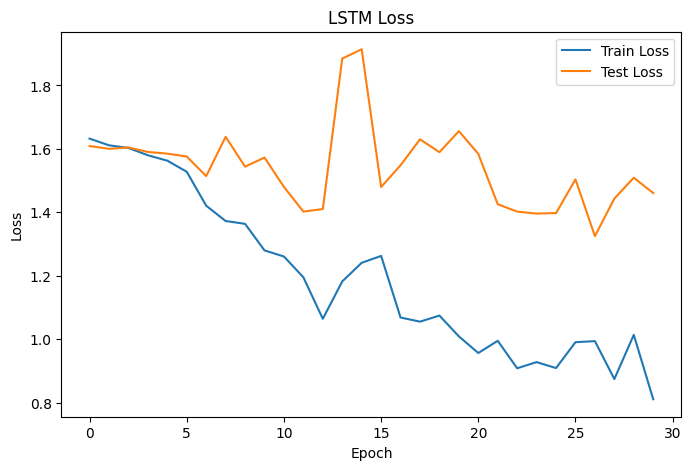

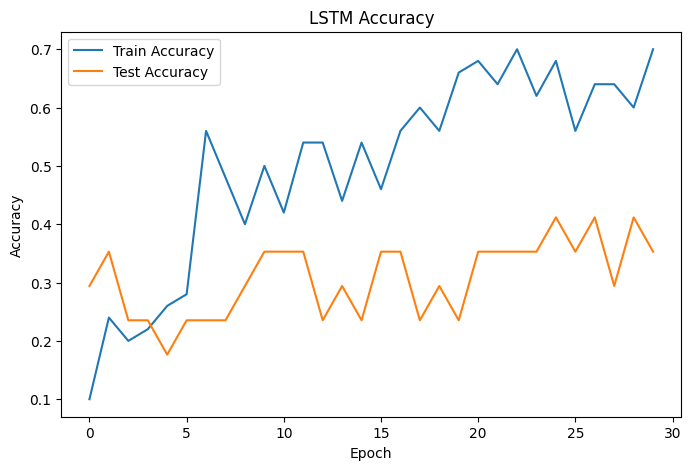

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["test_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy")
plt.legend()
plt.show()

## 15. Final evaluation

In [19]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_targets)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

print("Accuracy:", round(accuracy, 4))
print("Weighted Precision:", round(precision, 4))
print("Weighted Recall:", round(recall, 4))
print("Weighted F1-score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

Accuracy: 0.3529
Weighted Precision: 0.2941
Weighted Recall: 0.3529
Weighted F1-score: 0.2969

Classification Report:
              precision    recall  f1-score   support

      before       0.00      0.00      0.00         4
    computer       0.50      0.25      0.33         4
        cool       0.00      0.00      0.00         3
      cousin       0.50      1.00      0.67         3
       drink       0.50      0.67      0.57         3

    accuracy                           0.35        17
   macro avg       0.30      0.38      0.31        17
weighted avg       0.29      0.35      0.30        17



## 16. Confusion matrix

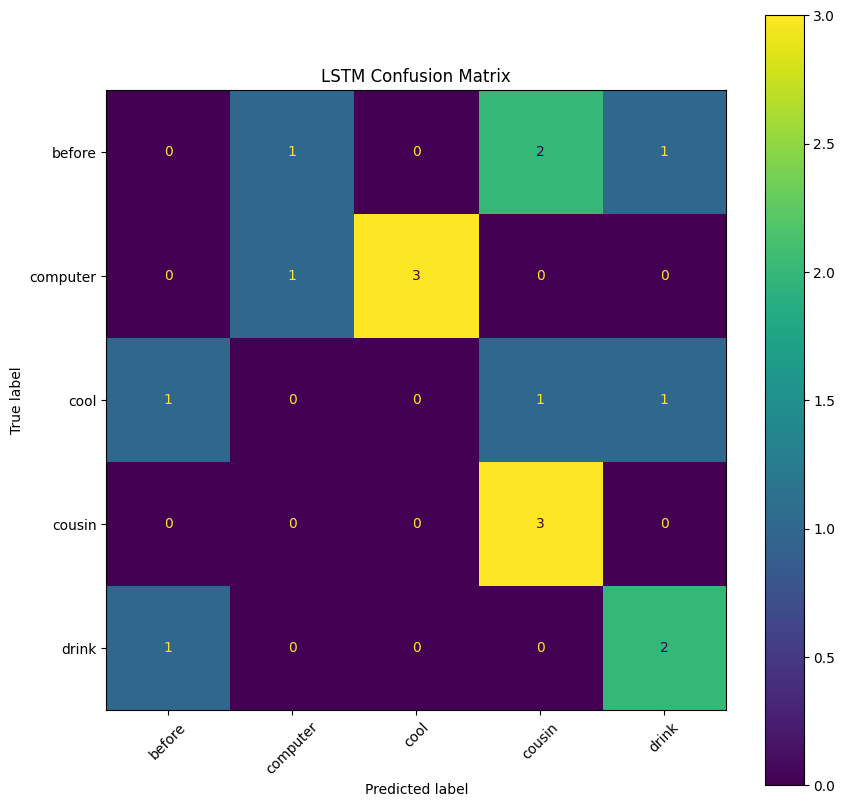

In [20]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("LSTM Confusion Matrix")
plt.show()

## 17. Save model

In [21]:
lstm_model_path = MODEL_DIR / "lstm_wlasl_landmark_model.pt"
lstm_encoder_path = MODEL_DIR / "lstm_label_encoder.joblib"
lstm_scaler_path = MODEL_DIR / "lstm_scaler.joblib"
lstm_metadata_path = MODEL_DIR / "lstm_metadata.json"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "num_classes": NUM_CLASSES,
        "dropout": DROPOUT,
        "bidirectional": True,
        "classes": list(label_encoder.classes_),
    },
    lstm_model_path,
)

joblib.dump(label_encoder, lstm_encoder_path)
joblib.dump(scaler, lstm_scaler_path)

metadata = {
    "model": "Bidirectional LSTM",
    "dataset": DATASET_NAME,
    "selected_classes": list(label_encoder.classes_),
    "feature_type": "MediaPipe Holistic landmark sequences",
    "sequence_length": int(MAX_FRAMES),
    "frame_stride": int(FRAME_STRIDE),
    "num_samples": int(len(y_labels)),
    "input_size": int(INPUT_SIZE),
    "hidden_size": int(HIDDEN_SIZE),
    "num_layers": int(NUM_LAYERS),
    "accuracy": float(accuracy),
    "weighted_precision": float(precision),
    "weighted_recall": float(recall),
    "weighted_f1": float(f1),
}

lstm_metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved model:", lstm_model_path)
print("Saved label encoder:", lstm_encoder_path)
print("Saved scaler:", lstm_scaler_path)
print("Saved metadata:", lstm_metadata_path)

Saved model: /workspace/dataset/ksl_project_data/models/lstm_wlasl_landmark_model.pt
Saved label encoder: /workspace/dataset/ksl_project_data/models/lstm_label_encoder.joblib
Saved scaler: /workspace/dataset/ksl_project_data/models/lstm_scaler.joblib
Saved metadata: /workspace/dataset/ksl_project_data/models/lstm_metadata.json
